In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("03.BaseDPEvolucaoMensalCisp.csv", encoding="iso-8859-1", sep=";")
df.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3


In [35]:
df.columns

Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        34848 non-null  int64  
 1   mes                         34848 non-null  int64  
 2   ano                         34848 non-null  int64  
 3   mes_ano                     34848 non-null  str    
 4   aisp                        34848 non-null  int64  
 5   risp                        34848 non-null  int64  
 6   munic                       34848 non-null  str    
 7   mcirc                       34848 non-null  int64  
 8   regiao                      34848 non-null  str    
 9   hom_doloso                  34848 non-null  int64  
 10  lesao_corp_morte            34848 non-null  int64  
 11  latrocinio                  34848 non-null  int64  
 12  cvli                        34848 non-null  int64  
 13  hom_por_interv_policial     34848 non-null

In [37]:
df_recuperacao_veiculos = df[["munic", "recuperacao_veiculos"]].groupby("munic").sum().reset_index().sort_values(by="recuperacao_veiculos", ascending=False)
df_recuperacao_veiculos_10_mais = df_recuperacao_veiculos.nlargest(10,"recuperacao_veiculos")
df_recuperacao_veiculos_10_mais

,munic,recuperacao_veiculos
68,Rio de Janeiro,269057
23,Duque de Caxias,42959
78,São Gonçalo,39574
81,São João de Meriti,19341
50,Nova Iguaçu,17217
48,Niterói,15417
6,Belford Roxo,14164
13,Campos dos Goytacazes,5334
47,Nilópolis,5257
43,Mesquita,5000


In [38]:
df_roubo_veiculo = df[["munic", "roubo_veiculo"]].groupby("munic").sum().reset_index().sort_values(by="roubo_veiculo", ascending=False)
df_roubo_veiculo_10_mais = df_roubo_veiculo.nlargest(10,"roubo_veiculo")
df_roubo_veiculo_10_mais

,munic,roubo_veiculo
68,Rio de Janeiro,372584
23,Duque de Caxias,62574
78,São Gonçalo,52539
50,Nova Iguaçu,40235
81,São João de Meriti,30151
6,Belford Roxo,22417
48,Niterói,21646
47,Nilópolis,11952
43,Mesquita,7825
27,Itaboraí,5914


In [39]:
df_comparacao = pd.merge(df_roubo_veiculo_10_mais, df_recuperacao_veiculos_10_mais, on="munic", how="outer")
df_comparacao = df_comparacao.sort_values(by="roubo_veiculo", ascending=False)
df_comparacao

,munic,roubo_veiculo,recuperacao_veiculos
8,Rio de Janeiro,372584.0,269057.0
2,Duque de Caxias,62574.0,42959.0
9,São Gonçalo,52539.0,39574.0
7,Nova Iguaçu,40235.0,17217.0
10,São João de Meriti,30151.0,19341.0
0,Belford Roxo,22417.0,14164.0
6,Niterói,21646.0,15417.0
5,Nilópolis,11952.0,5257.0
4,Mesquita,7825.0,5000.0
3,Itaboraí,5914.0,NaN


No geral, os municípios que mais sofrem com roubo de veículos, também são os municípios que mais recuperam carros. Não havendo grandes diferenças entre os 10 mais que sofrem roubos de veículos e os 10 mais que mais recuperam veículos roubados,

Vale destacar que os 3 primeiros municípios que mais sofrem com roubo de veículos (Rio de janeiro, Duque de Caxias e São Gonçalo: nessa ordem) são também os 3 que mais recuperam veículos roubados (mantida a mesma ordem, entre eles).

O município de Campos dos Goytacazes, que não está entre os 10 municípios que mais sofrem roubos de veículos, está entre os 10 municípios que mais recuperam veículos roubados.

Ao contrário, o município de Itaboraí, que está entre os 10 municípios que mais sofrem com roubo de veículos, não está entre os 10 municípios que mais recuperam veículos roubados.

In [40]:
df_recuperacao_veiculos_por_ano = df[["ano", "recuperacao_veiculos"]].groupby("ano").sum().reset_index().sort_values(by="ano", ascending=True)
df_recuperacao_veiculos_por_ano

,ano,recuperacao_veiculos
0,2003,29947
1,2004,26522
2,2005,26332
3,2006,26073
4,2007,24452
5,2008,21060
6,2009,19913
7,2010,16568
8,2011,16142
9,2012,17446


O ano com maior número de recuperação de veículos roubados foi 2017, com 37.630 veículos recuperados após roubo. O mesmo é seguido de perto pelo ano de 2018, cuja quantidade de veículos recuperados após roubo montou a 36.448.

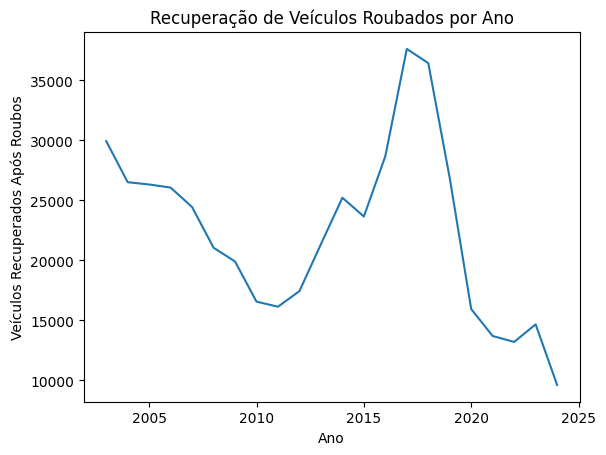

In [41]:
plt.title("Recuperação de Veículos Roubados por Ano")
plt.xlabel("Ano")
plt.ylabel("Veículos Recuperados Após Roubos")

plt.plot(df_recuperacao_veiculos_por_ano["ano"], df_recuperacao_veiculos_por_ano["recuperacao_veiculos"])

Como se pode observar do gráfico supra, há uma expansão na recuperação de veículos entre os anos 2011 e 2017 (havendo certa estabilidade entre os anos de 2017 e 2018). Desde então, a tendência é de queda no número de veículos roubados recuperados.

In [42]:
df_roubo_veiculo_por_ano = df[["ano", "roubo_veiculo"]].groupby("ano").sum().reset_index().sort_values(by="ano", ascending=True)
df_roubo_veiculo_por_ano

,ano,roubo_veiculo
0,2003,33531
1,2004,32408
2,2005,32690
3,2006,34324
4,2007,31490
5,2008,27847
6,2009,25036
7,2010,20052
8,2011,18773
9,2012,22065


In [43]:
df_comparacao_por_ano = pd.merge(df_roubo_veiculo_por_ano, df_recuperacao_veiculos_por_ano, on="ano", how="outer")
df_comparacao_por_ano = df_comparacao_por_ano.sort_values(by="ano", ascending=True)
df_comparacao_por_ano

,ano,roubo_veiculo,recuperacao_veiculos
0,2003,33531,29947
1,2004,32408,26522
2,2005,32690,26332
3,2006,34324,26073
4,2007,31490,24452
5,2008,27847,21060
6,2009,25036,19913
7,2010,20052,16568
8,2011,18773,16142
9,2012,22065,17446


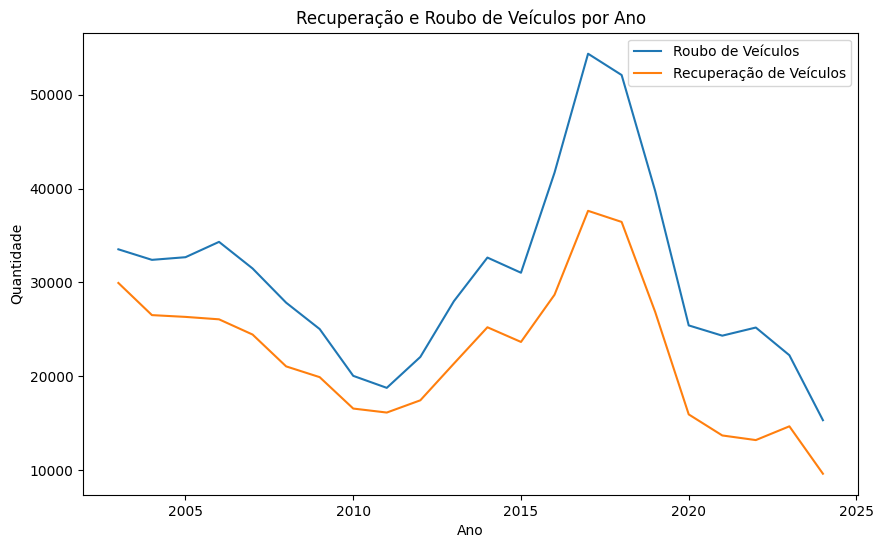

In [44]:
plt.figure(figsize=(10, 6))
plt.title("Recuperação e Roubo de Veículos por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade")

plt.plot(df_comparacao_por_ano['ano'], df_comparacao_por_ano["roubo_veiculo"], label="Roubo de Veículos")
plt.plot(df_comparacao_por_ano['ano'], df_comparacao_por_ano['recuperacao_veiculos'], label="Recuperação de Veículos")

plt.legend()
plt.show()


Como se pode observar do gráfico supra apresentado, o roubo de veículos e a recuperação de veículos caminham de forma sincronizadas.

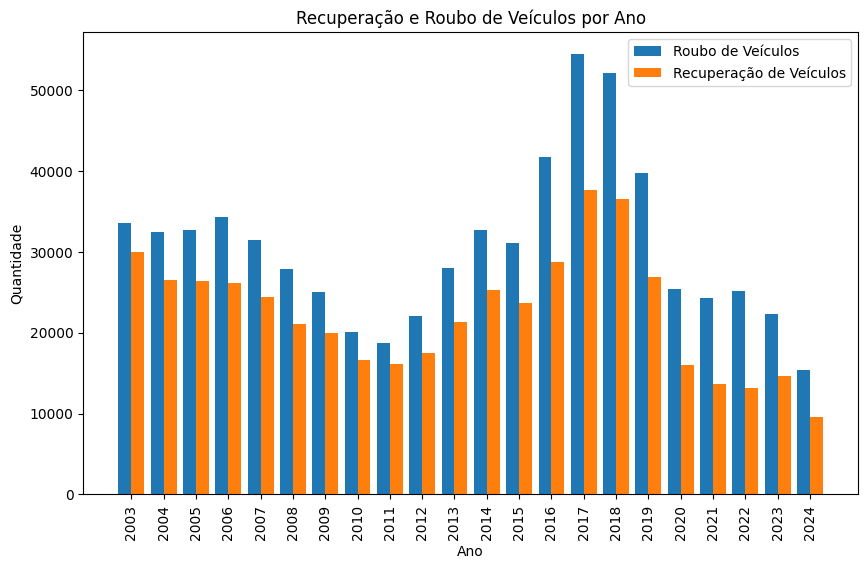

In [45]:
width = 0.4

plt.figure(figsize=(10, 6))
plt.title("Recuperação e Roubo de Veículos por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade")

plt.bar(df_comparacao_por_ano.index - width/2, df_comparacao_por_ano["roubo_veiculo"], width, label="Roubo de Veículos")
plt.bar(df_comparacao_por_ano.index + width/2, df_comparacao_por_ano["recuperacao_veiculos"], width, label="Recuperação de Veículos")
plt.xticks(df_comparacao_por_ano.index, df_comparacao_por_ano["ano"], rotation=90)

plt.legend()
plt.show()

Como se pode visualizar pelo gráfico de barras, tanto a recuperação de veículos, quanto os roubos de veículos têm seus picos nos anos de 2017 e 2018.

Houve uma queda acentuada em 2020, quando comparado a 2019, provavelmente, explicado pela pandemia, tanto no roubo de veículos, quanto na recuperação de veículos roubados. Essa queda foi mantida e estabilizada nesse nível, durante o período de 2021 a 2023. Em 2024, houve nova queda, tanto no número de veículos roubados, quanto no número de veículos recuperados após roubo.

In [48]:
df_media_roubo_veiculo = df_roubo_veiculo['roubo_veiculo'].mean()
print(f'A Média de Roubos de Veículos é de: {df_media_roubo_veiculo}')

A Média de Roubos de Veículos é de: 7448.2444444444445


In [51]:
df_outliers = df_roubo_veiculo[df_roubo_veiculo["roubo_veiculo"] > df_media_roubo_veiculo]
df_outliers

,munic,roubo_veiculo
68,Rio de Janeiro,372584
23,Duque de Caxias,62574
78,São Gonçalo,52539
50,Nova Iguaçu,40235
81,São João de Meriti,30151
6,Belford Roxo,22417
48,Niterói,21646
47,Nilópolis,11952
43,Mesquita,7825


No dataframe acima, temos uma lista de todos os municípios do Estado do Rio de Janeiro que tiveram um número de veículos roubados, entre 2003 e 2024, que ficaram acima da média. Portanto, são possíveis candidatos a serem outliers. Naturalmente, ter valor acima da média, não é uma garantia de ser um outlier. Porém, quando esse valor está algumas vezes acima da média, aí sim, temos um candidato a outlier.

In [52]:
df_outliers = df_roubo_veiculo[df_roubo_veiculo["roubo_veiculo"] > df_media_roubo_veiculo*4]
df_outliers

,munic,roubo_veiculo
68,Rio de Janeiro,372584
23,Duque de Caxias,62574
78,São Gonçalo,52539
50,Nova Iguaçu,40235
81,São João de Meriti,30151


No dataframe supra, estamos filtrando os municípios que estão 4 vezes acima da média, para roubo de veículos, no período entre 2003 e 2024.

No entanto, para termos maior precisão, uma vez que escolher 4 vezes a média é um tanto quanto arbitrário, far-se-á o cálculo do IQR e dos limites inferior e superior do Boxplot na sequência.

In [53]:
q1 = df_roubo_veiculo['roubo_veiculo'].quantile(0.25)
q3 = df_roubo_veiculo['roubo_veiculo'].quantile(0.75)

iqr = q3 - q1

lim_inf = q1 - 1.5*iqr
lim_sup = q3 + 1.5*iqr

print(f'O 1° Quartil é de: {q1}')
print(f'O 3° Quartil é de: {q3}')
print(f'O limite Inferior é do Boxplot: {lim_inf}')
print(f'O limite Superior do Boxplot é de: {lim_sup}')

O 1° Quartil é de: 47.0
O 3° Quartil é de: 989.5
O limite Inferior é do Boxplot: -1366.75
O limite Superior do Boxplot é de: 2403.25


Pelos dados acima, é necessário que a quantidade de roubos seja inferior a -1.367 roubos de veículos para ser considerado um outlier. Por conseguinte, nenhum município teve uma quantidade de roubos negativos. Logo, não há outliers no limite inferior.

Entretanto, o limite superior se mostrou problemático. Isso se justifica por estar muito abaixo da própria média. A média é de aproximadamente 7.448 veículos roubados, enquanto nosso limite superior, para descoberta de outliers, via boxplot, monta a aproximadamente 2.403 veículos roubados. Portanto, a média é mais de 3 vezes o limite superior. Dessa forma, qualquer município acima da média pode sim ser considerado um outlier. Portanto, iremos reproduzir abaixo a lista dos municípios, cuja a quantidade de veículos roubados está acima da média de veículos roubados.

In [54]:
df_outliers = df_roubo_veiculo[df_roubo_veiculo["roubo_veiculo"] > df_media_roubo_veiculo]
df_outliers

,munic,roubo_veiculo
68,Rio de Janeiro,372584
23,Duque de Caxias,62574
78,São Gonçalo,52539
50,Nova Iguaçu,40235
81,São João de Meriti,30151
6,Belford Roxo,22417
48,Niterói,21646
47,Nilópolis,11952
43,Mesquita,7825
